# 0. Prepare and check the JHH IMC data

Turns the QuPath-derived PhysiCell initial-condition CSVs into the AnnData `.h5ad`
form TissueMosaic consumes, then sanity-checks the result — the same shape of checks
as `TissueMosaic/notebooks/notebook1.ipynb`, but on this cohort.

**Sections**
1. Where the data comes from
2. **What the spatial coordinates actually are** — units, origin, axis orientation
3. Build the `.h5ad` files (deletes and regenerates)
4. Sanity checks — cohort overview
5. JHH369 in detail — tissue images and cell type composition
6. What TissueMosaic actually sees — the rasterised SparseImage

All shared logic lives in **`imc_tm.py`**, which this notebook imports; nothing is
reimplemented here. Run with the `tissue-mosaic-260819` environment.

## Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# imc_tm lives next to this notebook. NOTE: this directory is deliberately NOT a
# Python package -- it is named `tissuemosaic`, so adding an __init__.py would
# shadow the installed TissueMosaic library. Import these modules flat.
# resolve imc_tm from anywhere: repo root, tissuemosaic/, notebooks/, notebooks/archive/
_cands = [c for p in [Path.cwd(), *Path.cwd().parents] for c in (p, p / "tissuemosaic")]
sys.path.insert(0, str(next(c for c in _cands if (c / "imc_tm.py").exists())))
import imc_tm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import anndata
from anndata import read_h5ad

import warnings; warnings.filterwarnings("ignore")

print("repo    :", imc_tm.REPO)
print("python  :", sys.version.split()[0], "| numpy", np.__version__,
      "| pandas", pd.__version__, "| anndata", anndata.__version__)
print(imc_tm.compat_summary())

repo    : /home/gavehan/PDACAntigenPresentationABMs
python  : 3.10.20 | numpy 1.26.4 | pandas 2.3.3 | anndata 0.11.4
tm_compat: 34 numpy types allowlisted (weights_only stays True); relaxed only for test_dataset.pt, train_dataset.pt


### Channel definition is asserted against the training config

`imc_tm.CELL_TYPES` defines the image channel order. It must match
`categories_to_channels` in `config_dino_ssl_imc.yaml`, because a silent mismatch
would permute the channels and train the model on scrambled inputs with no visible
error. `imc_tm` asserts this **on import**; here it is explicitly.

In [2]:
check = imc_tm.check_channels()
print("config:", Path(check["config"]).name)
print("consistent:", check["ok"], "| problems:", check["problems"] or "none")
print()
for i, t in enumerate(imc_tm.CELL_TYPES):
    tag = "  (background/synthetic)" if t in imc_tm.BACKGROUND_TYPES else ""
    print(f"  ch {i}  {t}{tag}")

config: config_dino_ssl_imc.yaml
consistent: True | problems: none

  ch 0  CAF
  ch 1  apCAF
  ch 2  CD4_Tcell
  ch 3  CD8_Tcell
  ch 4  epithelial_tumor_class1
  ch 5  epithelial_tumor_class1_class2
  ch 6  mesenchymal_tumor_class1
  ch 7  mesenchymal_tumor_class1_class2
  ch 8  other_tissue  (background/synthetic)
  ch 9  duct_filler  (background/synthetic)


## 1. Where the data comes from

```
IMC .ome.tiff  --(segmentation + classification in QuPath)-->
qupath_detections/*_detections.txt                     <-- 54 marker channels + centroids
   --(assemble_initial_conditions.py: TYPE_MAP + duct hex-fill)-->
config/ics/JHH_IMC/<ROI>.csv                           <-- x, y, z, type, is_movable, volume
   --(imc_tm.build_anndata, this notebook)-->
tissuemosaic/imc_anndata/<ROI>.h5ad
```

The ICS CSV is a **lossy projection** of the IMC data: it keeps position, a cell-type
label and a volume, and drops all 54 marker intensities. `TYPE_MAP` also collapses
HLA-DR status on T cells (`CD4 T cell: HLA-DR` and `CD4 T cell: Other` both become
`CD4_Tcell`), while preserving it on tumour cells (`epithelial_tumor_class1` vs
`epithelial_tumor_class1_class2`) and CAFs (`CAF` vs `apCAF`) — which is where the
antigen-presentation signal lives.

In [3]:
print(f"QuPath detection files : {len(list(imc_tm.QUPATH_DIR.glob('*_detections.txt')))}")
print(f"canonical ICS CSVs     : {len(imc_tm.list_ics_csvs())}   (excludes '{imc_tm.SKIP_PATTERN}' variants)")
print()
print("ICS CSV schema:")
print(pd.read_csv(imc_tm.ICS_DIR / "JHH369ROI1.csv").head(3).to_string(index=False))

QuPath detection files : 56
canonical ICS CSVs     : 48   (excludes 'withductfiller' variants)

ICS CSV schema:
      x       y   z                           type  is_movable      volume
-481.45 -393.33 0.0        epithelial_tumor_class1           1 1323.171189
 -95.11 -311.97 0.0       mesenchymal_tumor_class1           1 1259.917726
-101.80  -20.01 0.0 epithelial_tumor_class1_class2           1 2118.189857


## 2. What the spatial coordinates actually are

Worth pinning down precisely, because the pixel size, the crop field-of-view and every
rendered image depend on it.

`assemble_initial_conditions.py` reads QuPath's **`Centroid X µm` / `Centroid Y µm`**,
which QuPath emits already micron-calibrated from the image's OME metadata, in the
standard image frame: **origin top-left, y increasing downward.** It then applies
(lines 173–175):

```python
cells['x'] = cells['x'] - img_w / 2      # centre horizontally
cells['y'] = img_h / 2 - cells['y']      # centre AND FLIP y
```

Note the sign on `y`. The claim to verify:

> **ICS coordinates are microns, origin at the ROI centre, y increasing upward.**

In [4]:
roi = "JHH369ROI1"
det = pd.read_table(imc_tm.QUPATH_DIR / "JHH369_ROI001_ROI_001.ome.tif_detections.txt")
ics = pd.read_csv(imc_tm.ICS_DIR / f"{roi}.csv")

qx, qy = det["Centroid X µm"].values, det["Centroid Y µm"].values
print(f"QuPath raw X : {qx.min():8.2f} .. {qx.max():8.2f} um   (span {qx.max()-qx.min():.1f})")
print(f"QuPath raw Y : {qy.min():8.2f} .. {qy.max():8.2f} um   (span {qy.max()-qy.min():.1f})")
print(f"detections   : {len(det)}")
print()
# the ICS also contains synthetic duct_filler cells, which have no QuPath source
real = ics[ics["type"] != "duct_filler"]
print(f"ICS non-filler cells : {len(real)}   (matches detections: {len(real) == len(det)})")
print(f"ICS X : {real.x.min():8.2f} .. {real.x.max():8.2f} um")
print(f"ICS Y : {real.y.min():8.2f} .. {real.y.max():8.2f} um")

QuPath raw X :    -3.52 ..  1097.10 um   (span 1100.6)
QuPath raw Y :    -1.38 ..  1096.40 um   (span 1097.8)
detections   : 7768

ICS non-filler cells : 7768   (matches detections: True)
ICS X :  -553.52 ..   547.10 um
ICS Y :  -546.40 ..   551.38 um


### 2a. Reconstruct the transform

In [5]:
domains = imc_tm.load_roi_domains()
x0, x1, y0, y1 = domains[roi]
W, H = x1 - x0, y1 - y0
print(f"{roi} declared domain: {W:.0f} x {H:.0f} um  (x {x0:.0f}..{x1:.0f}, y {y0:.0f}..{y1:.0f})")

# apply the documented transform, then compare as sorted sets (row order may differ)
rx, ry = np.sort(qx - W / 2), np.sort(H / 2 - qy)
ax_, ay = np.sort(real.x.values), np.sort(real.y.values)

print()
print(f"x  max|reconstructed - actual| = {np.abs(rx - ax_).max():.12f} um")
print(f"y  max|reconstructed - actual| = {np.abs(ry - ay).max():.12f} um")
print(f"y  same, but WITHOUT the flip   = {np.abs(np.sort(qy - H/2) - ay).max():.4f} um   <-- large, so the flip is real")

assert np.abs(rx - ax_).max() < 1e-9 and np.abs(ry - ay).max() < 1e-9, "coordinate transform does not reproduce"
print("\nASSERTION PASSED: the documented transform reproduces the ICS exactly.")

JHH369ROI1 declared domain: 1100 x 1100 um  (x -550..550, y -550..550)

x  max|reconstructed - actual| = 0.000000000000 um
y  max|reconstructed - actual| = 0.000000000000 um
y  same, but WITHOUT the flip   = 64.3200 um   <-- large, so the flip is real

ASSERTION PASSED: the documented transform reproduces the ICS exactly.


### 2b. Visual confirmation of the y-flip

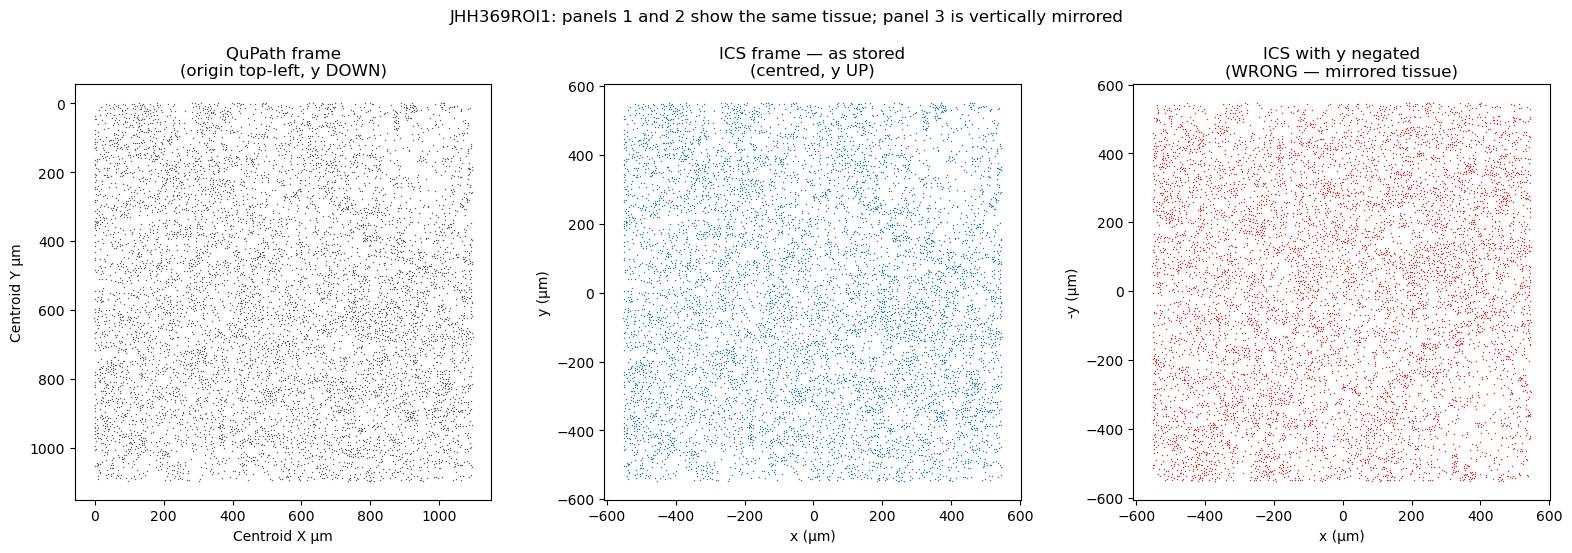

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
axes[0].scatter(qx, qy, s=1, c="0.35", linewidths=0)
axes[0].invert_yaxis()          # draw the image frame as an image: y down
axes[0].set_title("QuPath frame\n(origin top-left, y DOWN)")
axes[0].set_xlabel("Centroid X µm"); axes[0].set_ylabel("Centroid Y µm")

axes[1].scatter(real.x, real.y, s=1, c="C0", linewidths=0)
axes[1].set_title("ICS frame — as stored\n(centred, y UP)")
axes[1].set_xlabel("x (µm)"); axes[1].set_ylabel("y (µm)")

axes[2].scatter(real.x, -real.y, s=1, c="C3", linewidths=0)
axes[2].set_title("ICS with y negated\n(WRONG — mirrored tissue)")
axes[2].set_xlabel("x (µm)"); axes[2].set_ylabel("-y (µm)")

for a in axes: a.set_aspect("equal")
plt.suptitle(f"{roi}: panels 1 and 2 show the same tissue; panel 3 is vertically mirrored", y=1.02)
plt.tight_layout()

**Conclusion.**

| property | value |
|---|---|
| units | **microns** (QuPath OME calibration; IMC is ~1 µm/pixel) |
| origin | **ROI centre**, `(0, 0)` |
| x axis | increases right |
| y axis | **increases upward** (already flipped out of the image frame) |
| `volume` | sphere volume from QuPath `Max diameter µm`, i.e. `(π/6)·d³`, in µm³ |

**Practical consequence:** plot `y` as-is. Matplotlib's default (y up) reproduces the
tissue in its original anatomical orientation. Do *not* `invert_yaxis()` on ICS
coordinates and do not negate `y`; for rasterised images use `origin='lower'`.
`imc_tm.plot_tissue` and `imc_tm.plot_channels` both follow this.

### 2c. ROI domains are not uniform

In [7]:
dom = pd.DataFrame([{"roi": r, "x_min": v[0], "x_max": v[1], "y_min": v[2], "y_max": v[3]}
                    for r, v in domains.items()])
dom["W"] = dom.x_max - dom.x_min; dom["H"] = dom.y_max - dom.y_min
print("declared ROI domain sizes across the cohort:")
print(dom.groupby(["W", "H"]).size().rename("n_ROIs").reset_index().to_string(index=False))
print()
print("JHH369:")
print(dom[dom.roi.str.startswith("JHH369")].to_string(index=False))
print()
print("Only absolute coordinates are affected. SparseImage derives its own bounding box")
print("from the data plus padding, so differing domains are harmless.")

declared ROI domain sizes across the cohort:
     W      H  n_ROIs
1000.0  580.0       1
1000.0 1000.0      25
1100.0 1100.0      22

JHH369:
       roi  x_min  x_max  y_min  y_max      W      H
JHH369ROI1 -550.0  550.0 -550.0  550.0 1100.0 1100.0
JHH369ROI2 -550.0  550.0 -550.0  550.0 1100.0 1100.0
JHH369ROI3 -550.0  550.0 -550.0  550.0 1100.0 1100.0
JHH369ROI4 -550.0  550.0 -550.0  550.0 1100.0 1100.0

Only absolute coordinates are affected. SparseImage derives its own bounding box
from the data plus padding, so differing domains are harmless.


## 3. Build the `.h5ad` files

`imc_tm.build_anndata()` **deletes** any previous `.h5ad` and the
`train_dataset.pt` / `test_dataset.pt` caches, then regenerates from the canonical
CSVs — so the output never mixes generations. The same function backs the headless
CLI, `python tissuemosaic/make_imc_anndata.py`.

Two ROIs are excluded: `JHH387ROI1_withductfiller.csv` and `..._not_movable.csv` are
variants of an ROI already in the set, they carry the only NaN coordinate rows (1386
each), and they are the only source of `epithelial_normal`, which no other ROI has.

In [8]:
summary = imc_tm.build_anndata(verbose=True)
summary.head()

48 ROIs from 14 patients
ROI domains loaded for 48 ROIs
removed 50 stale file(s) from /home/gavehan/PDACAntigenPresentationABMs/tissuemosaic/imc_anndata


wrote 48 h5ad files, 357,274 cells total, to /home/gavehan/PDACAntigenPresentationABMs/tissuemosaic/imc_anndata
channels (10): CAF, apCAF, CD4_Tcell, CD8_Tcell, epithelial_tumor_class1, epithelial_tumor_class1_class2, mesenchymal_tumor_class1, mesenchymal_tumor_class1_class2, other_tissue, duct_filler


,roi,patient,status,n_cells
0,JHH317ROI1,JHH317,0,4202
1,JHH317ROI2,JHH317,0,2632
2,JHH317ROI3,JHH317,0,10893
3,JHH317ROI4,JHH317,0,10633
4,JHH352ROI1,JHH352,1,6992


## 4. Sanity checks — cohort overview

In [9]:
adatas = imc_tm.load_all_anndata()
meta = imc_tm.roi_metadata(adatas)
print(f"loaded {len(adatas)} ROIs | {meta.patient.nunique()} patients | {meta.n_cells.sum():,} cells")
print(f"cells/ROI: min {meta.n_cells.min():,}  median {int(meta.n_cells.median()):,}  max {meta.n_cells.max():,}")
meta.head(8)

loaded 48 ROIs | 14 patients | 357,274 cells
cells/ROI: min 2,632  median 7,469  max 13,686


,roi,patient,status,n_cells,x_span,y_span
0,JHH317ROI1,JHH317,0,4202,995.431400,578.5300
1,JHH317ROI2,JHH317,0,2632,997.286000,998.4882
2,JHH317ROI3,JHH317,0,10893,1002.678367,1002.0000
3,JHH317ROI4,JHH317,0,10633,1002.462367,998.4700
4,JHH352ROI1,JHH352,1,6992,999.383000,999.7120
5,JHH352ROI2,JHH352,1,10047,999.284000,998.5100
6,JHH352ROI3,JHH352,1,6008,998.995000,998.8570
7,JHH352ROI4,JHH352,1,11070,1001.987000,1002.1680


### One AnnData object, in full

In [10]:
a = adatas["JHH369ROI1"]
print(a)
print()
print("uns (provenance):")
for k, v in a.uns.items():
    print(f"  {k:20s} {v}")
print()
print("obs head:");  print(a.obs.head(3).to_string())
print()
print("obsm['cell_type_proportions'] head (one-hot):")
print(a.obsm["cell_type_proportions"].head(3).to_string())

AnnData object with n_obs × n_vars = 8025 × 0
    obs: 'x', 'y', 'cell_type', 'volume'
    uns: 'coord_origin', 'coord_source', 'coord_units', 'coord_y_axis', 'n_dropped_nan_rows', 'patient', 'roi', 'roi_domain_um', 'status'
    obsm: 'cell_type_proportions'

uns (provenance):
  coord_origin         ROI centre (0, 0)
  coord_source         QuPath 'Centroid X/Y um' -> assemble_initial_conditions.py
  coord_units          micron
  coord_y_axis         increases upward (flipped from QuPath image y-down)
  n_dropped_nan_rows   0
  patient              JHH369
  roi                  JHH369ROI1
  roi_domain_um        [-550.  550. -550.  550.]
  status               6

obs head:
        x       y                       cell_type       volume
0 -481.45 -393.33         epithelial_tumor_class1  1323.171189
1  -95.11 -311.97        mesenchymal_tumor_class1  1259.917726
2 -101.80  -20.01  epithelial_tumor_class1_class2  2118.189857

obsm['cell_type_proportions'] head (one-hot):
   CAF  apCAF  CD4_Tc

### Schema checks that must hold for TissueMosaic

In [11]:
rows = []
for r, a in adatas.items():
    oh = a.obsm["cell_type_proportions"]
    rows.append({
        "roi": r,
        "obs_xy": {"x", "y"}.issubset(a.obs.columns),
        "obsm_is_df": isinstance(oh, pd.DataFrame),
        "cols_match_imc_tm": list(oh.columns) == imc_tm.CELL_TYPES,
        "onehot": bool(np.allclose(oh.values.sum(axis=1), 1.0)),
        "finite_xy": bool(np.isfinite(a.obs.x).all() and np.isfinite(a.obs.y).all()),
        "status_int": isinstance(a.uns["status"], (int, np.integer)),
        "has_provenance": "coord_units" in a.uns,
    })
chk = pd.DataFrame(rows).set_index("roi")
print("all schema checks pass on all ROIs:", bool(chk.all().all()))
print(chk.all().to_string())
assert chk.all().all(), chk[~chk.all(axis=1)]

all schema checks pass on all ROIs: True
obs_xy               True
obsm_is_df           True
cols_match_imc_tm    True
onehot               True
finite_xy            True
status_int           True
has_provenance       True


### Cohort-wide cell type composition

In [12]:
comp = imc_tm.composition(adatas)
frac = imc_tm.composition(adatas, fraction=True)

summary_tbl = pd.DataFrame({
    "total_cells": comp.sum(),
    "mean_frac": frac.mean(),
    "max_frac": frac.max(),
    "ROIs_with_>=10": (comp >= 10).sum(),
}).sort_values("total_cells", ascending=False)
print(summary_tbl.to_string(float_format=lambda v: f"{v:.3f}"))
print()
bg = frac[list(imc_tm.BACKGROUND_TYPES)].sum(axis=1).mean()
print(f"other_tissue + duct_filler together are {bg:.1%} of cells on average.")
print("duct_filler is synthetic (hex-packed into duct polygons); other_tissue is")
print("unclassified. The antigen-presentation signal lives in the minority channels.")

                                 total_cells  mean_frac  max_frac  ROIs_with_>=10
cell_type                                                                        
other_tissue                          195500      0.572     0.943              48
duct_filler                            59709      0.142     0.594              41
CAF                                    30008      0.079     0.287              45
CD4_Tcell                              17106      0.048     0.223              42
CD8_Tcell                              14328      0.040     0.149              42
epithelial_tumor_class1                13524      0.047     0.338              48
apCAF                                  12645      0.033     0.119              41
mesenchymal_tumor_class1                9930      0.024     0.131              33
epithelial_tumor_class1_class2          3495      0.012     0.105              40
mesenchymal_tumor_class1_class2         1029      0.003     0.015              21

other_tissue + 

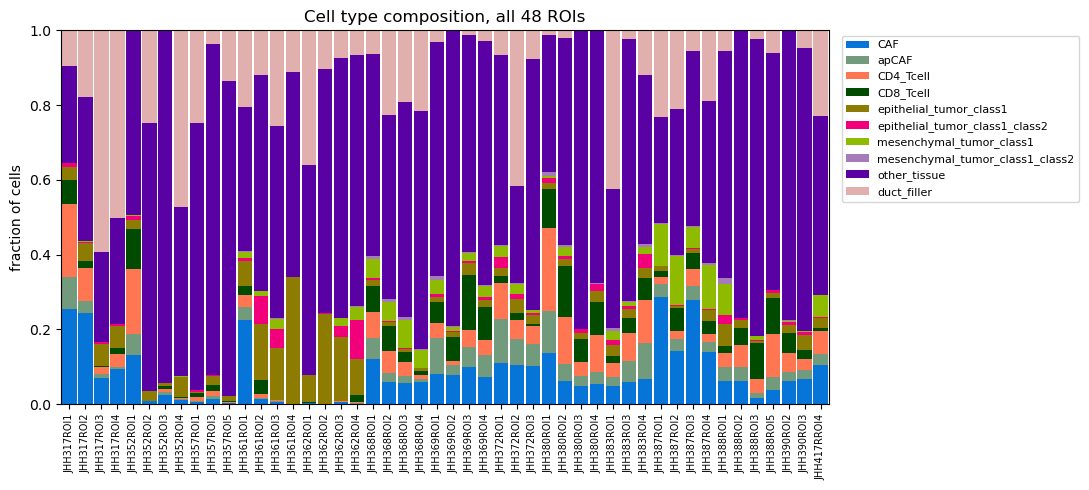

In [13]:
colors = imc_tm.palette()
fig, ax = plt.subplots(figsize=(11, 5))
fs = frac.loc[sorted(frac.index)]
bottom = np.zeros(len(fs))
for t in imc_tm.CELL_TYPES:
    ax.bar(range(len(fs)), fs[t].values, bottom=bottom, label=t, color=colors[t], width=0.9)
    bottom += fs[t].values
ax.set_xticks(range(len(fs))); ax.set_xticklabels(fs.index, rotation=90, fontsize=7)
ax.set_ylabel("fraction of cells"); ax.set_xlim(-0.5, len(fs) - 0.5); ax.set_ylim(0, 1)
ax.set_title("Cell type composition, all 48 ROIs")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()

## 5. JHH369 in detail

Four ROIs from one patient, each 1100 × 1100 µm.

In [14]:
J = [r for r in sorted(adatas) if r.startswith("JHH369")]
print("JHH369 ROIs:", J)
print()
print(meta[meta.roi.isin(J)].set_index("roi")[["n_cells", "x_span", "y_span"]]
      .to_string(float_format=lambda v: f"{v:.1f}"))

JHH369 ROIs: ['JHH369ROI1', 'JHH369ROI2', 'JHH369ROI3', 'JHH369ROI4']

            n_cells  x_span  y_span
roi                                
JHH369ROI1     8025  1100.6  1100.4
JHH369ROI2     6383  1098.4  1098.5
JHH369ROI3     7572  1099.7  1100.1
JHH369ROI4     8724  1098.6  1100.5


### 5a. Tissue images — all cell types

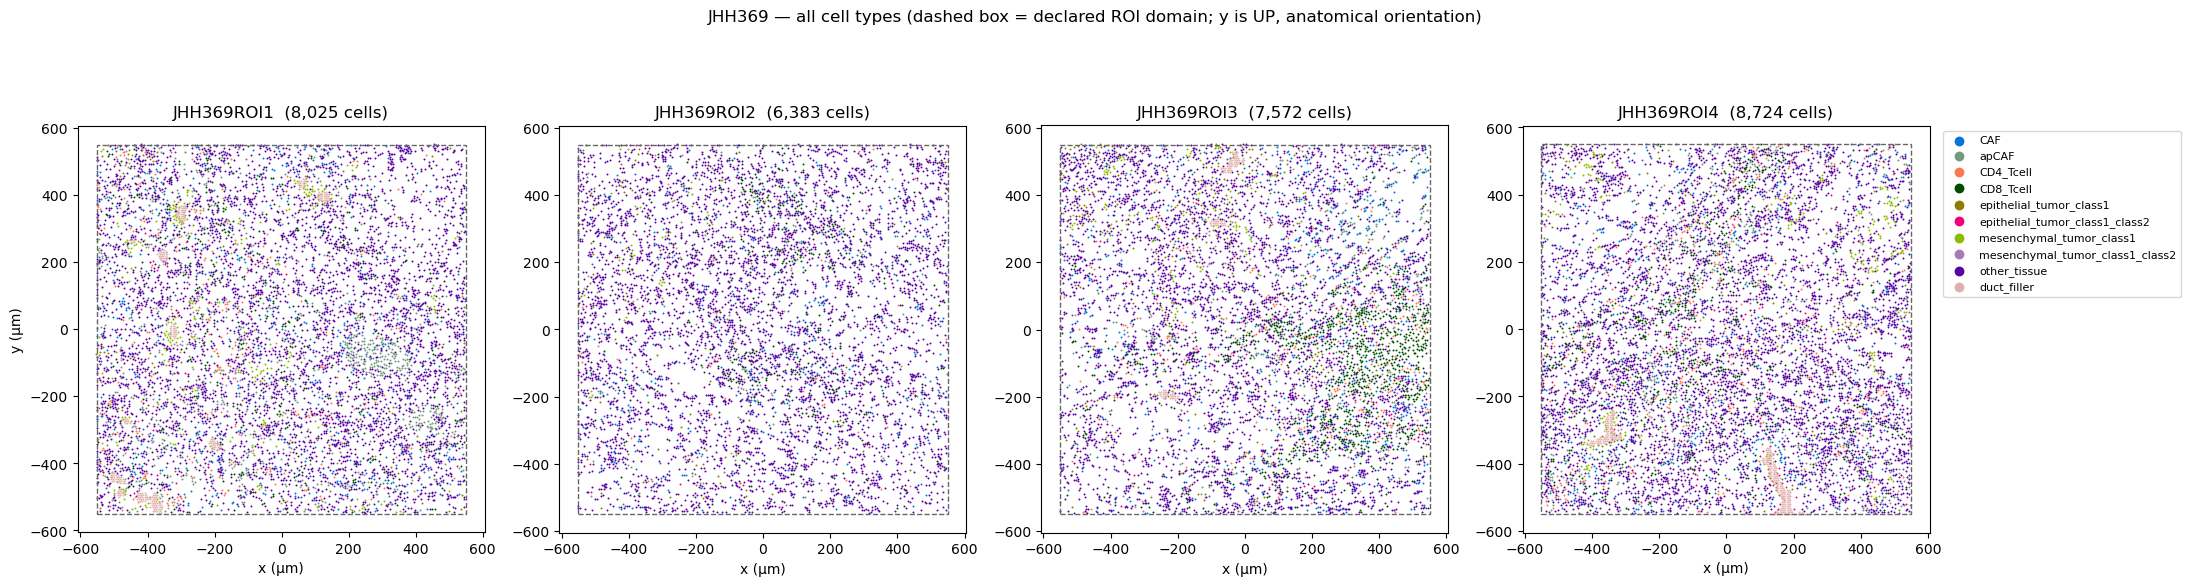

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.8))
for ax, r in zip(axes, J):
    imc_tm.plot_tissue(adatas[r], ax=ax, domain=domains[r], colors=colors)
    ax.set_title(f"{r}  ({adatas[r].n_obs:,} cells)")
    if r != J[0]: ax.set_ylabel("")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=5, fontsize=8)
plt.suptitle("JHH369 — all cell types (dashed box = declared ROI domain; y is UP, anatomical orientation)", y=1.03)
plt.tight_layout()

### 5b. Tissue images — biology only

`other_tissue` and `duct_filler` dominate by count and hide the structure. Same ROIs,
with those two greyed out.

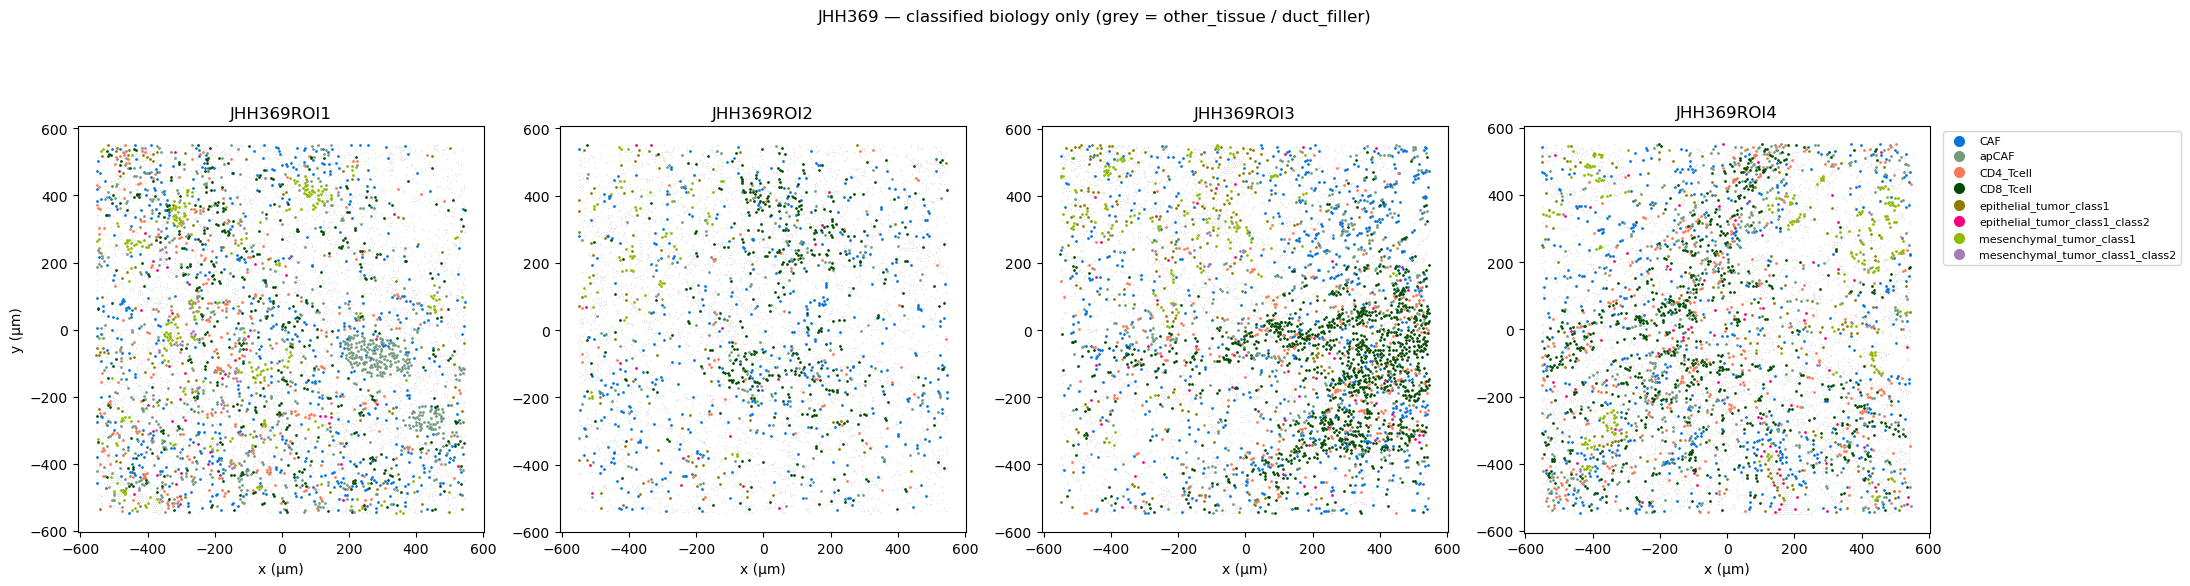

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.8))
for ax, r in zip(axes, J):
    imc_tm.plot_tissue(adatas[r], ax=ax, biology_only=True, colors=colors)
    ax.set_title(r)
    if r != J[0]: ax.set_ylabel("")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=4, fontsize=8)
plt.suptitle("JHH369 — classified biology only (grey = other_tissue / duct_filler)", y=1.03)
plt.tight_layout()

### 5c. Cell type composition, JHH369

In [17]:
jcomp, jfrac = comp.loc[J], frac.loc[J]
print("counts:");    print(jcomp.to_string())
print()
print("fractions:"); print(jfrac.to_string(float_format=lambda v: f"{v:.3f}"))

counts:
cell_type   CAF  apCAF  CD4_Tcell  CD8_Tcell  epithelial_tumor_class1  epithelial_tumor_class1_class2  mesenchymal_tumor_class1  mesenchymal_tumor_class1_class2  other_tissue  duct_filler
JHH369ROI1  636    789        308        462                      114                              44                       312                               86          5017          257
JHH369ROI2  490    177         63        417                       86                              18                        72                                4          5056            0
JHH369ROI3  760    405        325       1126                      232                              56                       166                               20          4381          101
JHH369ROI4  625    512        369        756                      164                              78                       243                               28          5700          249

fractions:
cell_type    CAF  apCAF  CD4_Tcell  CD8_

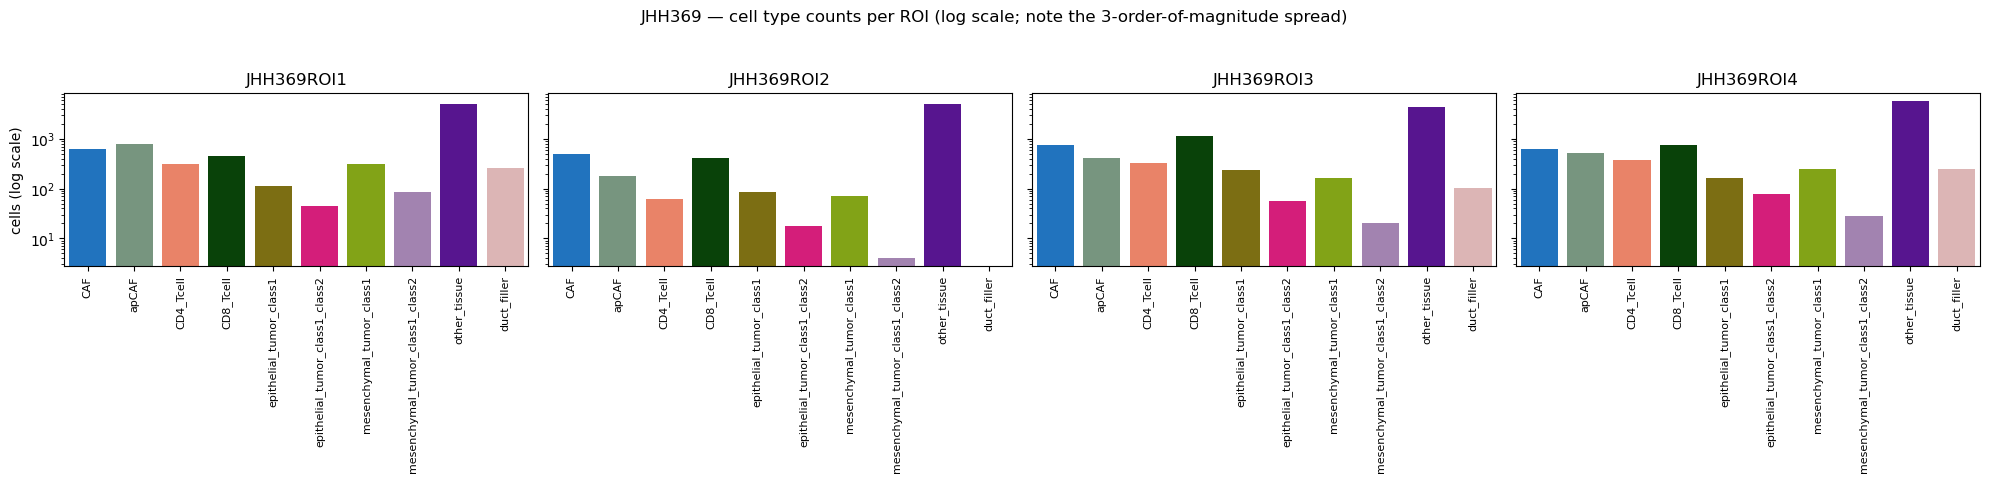

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6), sharey=True)
for ax, r in zip(axes, J):
    v = jcomp.loc[r]
    seaborn.barplot(x=np.asarray(v.index), y=v.to_numpy(), ax=ax,
                    palette=[colors[t] for t in v.index])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
    ax.set_title(r); ax.set_yscale("log")
axes[0].set_ylabel("cells (log scale)")
plt.suptitle("JHH369 — cell type counts per ROI (log scale; note the 3-order-of-magnitude spread)", y=1.04)
plt.tight_layout()

### 5d. Antigen-presentation readouts

The distinctions this project cares about: MHC-II status on tumour cells
(`*_class1` vs `*_class1_class2`) and antigen-presenting CAFs (`CAF` vs `apCAF`).

            epithelial class1+2 / all epithelial  mesenchymal class1+2 / all mesenchymal  apCAF / all CAF  CD8 / (CD4+CD8)
JHH369ROI1                                 0.278                                   0.216            0.554            0.600
JHH369ROI2                                 0.173                                   0.053            0.265            0.869
JHH369ROI3                                 0.194                                   0.108            0.348            0.776
JHH369ROI4                                 0.322                                   0.103            0.450            0.672


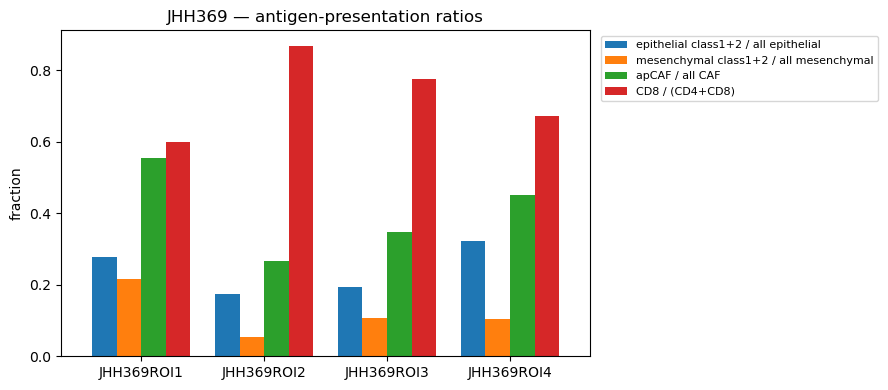

In [19]:
def ratio(num, den):
    tot = num + den
    return np.where(tot > 0, num / np.maximum(tot, 1), np.nan)

ap = pd.DataFrame({
    "epithelial class1+2 / all epithelial": ratio(
        jcomp["epithelial_tumor_class1_class2"].values, jcomp["epithelial_tumor_class1"].values),
    "mesenchymal class1+2 / all mesenchymal": ratio(
        jcomp["mesenchymal_tumor_class1_class2"].values, jcomp["mesenchymal_tumor_class1"].values),
    "apCAF / all CAF": ratio(jcomp["apCAF"].values, jcomp["CAF"].values),
    "CD8 / (CD4+CD8)": ratio(jcomp["CD8_Tcell"].values, jcomp["CD4_Tcell"].values),
}, index=J)
print(ap.to_string(float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(figsize=(9, 4))
ap.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("fraction"); ax.set_title("JHH369 — antigen-presentation ratios")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=0); plt.tight_layout()

## 6. What TissueMosaic actually sees

`SparseImage` rasterises the point cloud into a multi-channel image at `pixel_size`
µm/pixel — one channel per cell type. This is the model's input.

In [20]:
cfg = imc_tm.load_config()
dm = imc_tm.make_datamodule(cfg)
sp = dm.anndata_to_sparseimage(adatas["JHH369ROI1"])

print(f"pixel_size      : {cfg['pixel_size']} um/pixel")
print(f"channels (ch_in): {dm.ch_in}")
print(f"image shape     : {tuple(sp.data.shape)}   (C, H, W)")
print(f"physical extent : {sp.data.shape[-1]*cfg['pixel_size']:.0f} x {sp.data.shape[-2]*cfg['pixel_size']:.0f} um")
print(f"global crop     : {cfg['global_size']} px = {cfg['global_size']*cfg['pixel_size']:.0f} um")
print(f"local crop      : {cfg['local_size']} px = {cfg['local_size']*cfg['pixel_size']:.0f} um")

[neptune] [warning] NeptuneDeprecationWarning: The 'neptune-client' package has been deprecated and will be removed in the future. Install the 'neptune' package instead. For more, see https://docs-legacy.neptune.ai/setup/upgrading/
[neptune] [warning] NeptuneDeprecationWarning: You're importing the Neptune client library via the deprecated `neptune.new` module, which will be removed in a future release. Import directly from `neptune` instead.


number of elements ---> 8025
mean and median spacing 7.24660801409835, 6.800890061414151


The dense shape of the image is -> torch.Size([10, 581, 581])
pixel_size      : 2.0 um/pixel
channels (ch_in): 10
image shape     : (10, 581, 581)   (C, H, W)
physical extent : 1162 x 1162 um
global crop     : 96 px = 192 um
local crop      : 64 px = 128 um


Text(0.5, 0.98, "JHH369ROI1 as TissueMosaic sees it — 10 channels @ 2.0 µm/px (origin='lower' keeps the anatomical orientation)")

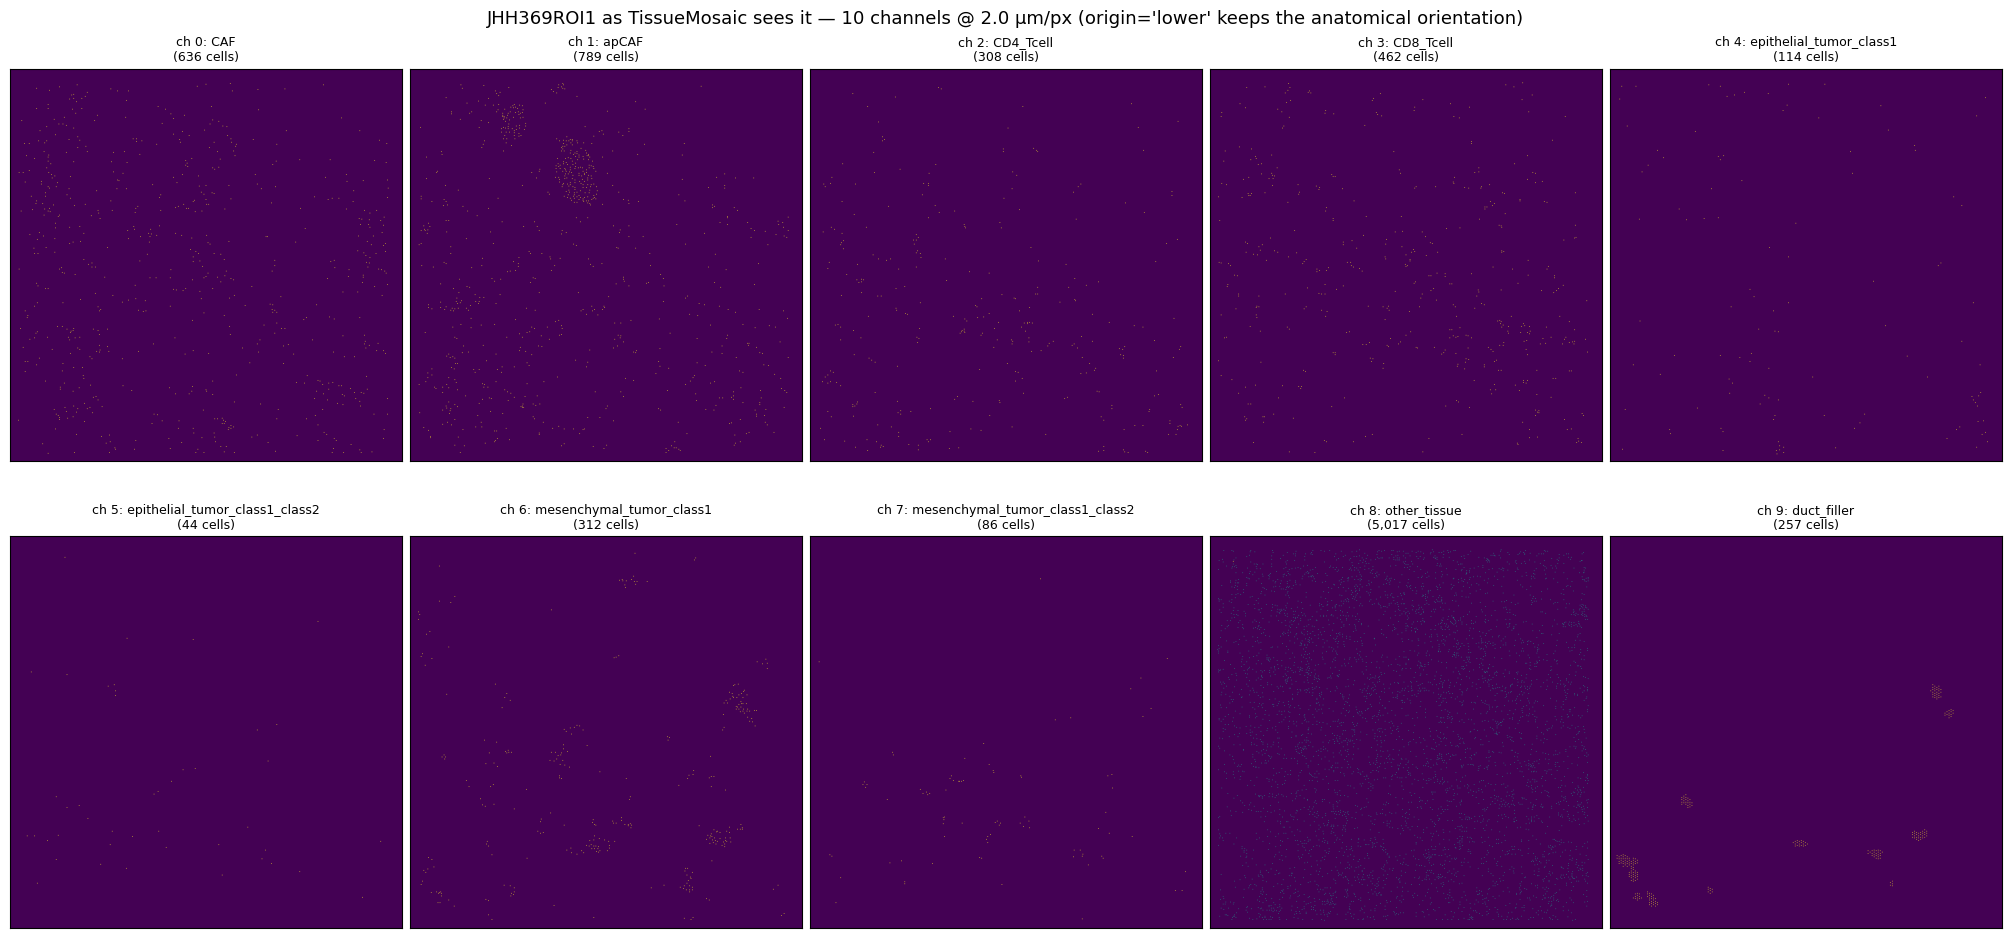

In [21]:
fig, _ = imc_tm.plot_channels(sp, figsize=(20, 9.6))
fig.suptitle(f"JHH369ROI1 as TissueMosaic sees it — {dm.ch_in} channels @ {cfg['pixel_size']} µm/px "
             f"(origin='lower' keeps the anatomical orientation)", fontsize=13)

## Summary

- **Coordinates are microns**, origin at the ROI centre, **y increasing upward** —
  verified by exact reconstruction from the QuPath detections (`max|diff| = 0`, asserted
  above). Plot `y` as-is; never `invert_yaxis()` or negate it.
- **48 ROIs, 14 patients, 357,274 cells** written to `tissuemosaic/imc_anndata/`, each
  carrying its coordinate provenance in `.uns`.
- **10 cell-type channels**, one-hot in `obsm['cell_type_proportions']`, in an order
  asserted to match `config_dino_ssl_imc.yaml`.
- ROI domains vary (1000×1000, 1100×1100, one 1000×580); harmless.
- Composition is heavily skewed — `other_tissue` + `duct_filler` are ~71% of cells.

**Next:** `1.train_ssl.ipynb` — train the DINO model on these h5ad files.